In [ ]:


from google.colab import drive
drive.mount('/content/drive')
!ls /content/drive/MyDrive
!unzip /content/drive/MyDrive/audio_dataset.zip -d /content/dataset
!ls /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/Indian_Languages_Audio_Dataset/Marathi/1002.mp3  
  inflating: /content/dataset/Indian_Languages_Audio_Dataset/Marathi/10087.mp3  
  inflating: /content/dataset/Indian_Languages_Audio_Dataset/Marathi/1013.mp3  
  inflating: /content/dataset/Indian_Languages_Audio_Dataset/Marathi/10167.mp3  
  inflating: /content/dataset/Indian_Languages_Audio_Dataset/Marathi/10176.mp3  
  inflating: /content/dataset/Indian_Languages_Audio_Dataset/Marathi/10192.mp3  
  inflating: /content/dataset/Indian_Languages_Audio_Dataset/Marathi/10229.mp3  
  inflating: /content/dataset/Indian_Languages_Audio_Dataset/Marathi/1024.mp3  
  inflating: /content/dataset/Indian_Languages_Audio_Dataset/Marathi/1027.mp3  
  inflating: /content/dataset/Indian_Languages_Audio_Dataset/Marathi/10291.mp3  
  inflating: /content/dataset/Indian_Languages_Audio_Dataset/Marathi/10294.mp3  
  inflating: /content/dataset/Indian_Languages_Audio_Dataset/M

In [ ]:
import os
import librosa
import numpy as np
from tqdm import tqdm
dataset_path = "/content/dataset/Indian_Languages_Audio_Dataset"

print(os.listdir(dataset_path))

features = []
labels = []

for language in os.listdir(dataset_path):

    language_path = os.path.join(dataset_path, language)

    for file in tqdm(os.listdir(language_path)):

        if file.endswith(".mp3"):

            file_path = os.path.join(language_path, file)

            try:
                audio, sr = librosa.load(file_path, duration=3)

                mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

                mfcc_scaled = np.mean(mfcc.T, axis=0)

                features.append(mfcc_scaled)
                labels.append(language)

            except:
                print("Skipping:", file_path)

X = np.array(features)
y = np.array(labels)

print("Features:", X.shape)
print("Labels:", y.shape)

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print(y_encoded[:10])

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

['Urdu', 'Gujarati', 'Tamil', 'Malayalam', 'Bengali', 'Telugu', 'Marathi', 'Hindi', 'Kannada', 'Punjabi']


100%|██████████| 1000/1000 [00:29<00:00, 34.27it/s]


Features: (10000, 40)
Labels: (10000,)
[9 9 9 9 9 9 9 9 9 9]
(8000, 40)
(2000, 40)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create model
model = RandomForestClassifier(n_estimators=200, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8415


In [ ]:
!pip install tensorflow librosa
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
y_categorical = to_categorical(y_encoded)

print(y_categorical.shape)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_categorical,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

model = Sequential()

model.add(Dense(256, activation='relu', input_shape=(40,)))
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))

model.add(Dense(y_categorical.shape[1], activation='softmax'))

model.summary()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

(10000, 10)
(8000, 40)
(2000, 40)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,298 (204.29 KB)

 Trainable params: 52,298 (204.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.2208 - loss: 3.9243 - val_accuracy: 0.3585 - val_loss: 1.7875
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3774 - loss: 1.7462 - val_accuracy: 0.5295 - val_loss: 1.3658
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4950 - loss: 1.4039 - val_accuracy: 0.6410 - val_loss: 1.0280
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5685 - loss: 1.1695 - val_accuracy: 0.7015 - val_loss: 0.8503
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6409 - loss: 0.9696 - val_accuracy: 0.7440 - val_loss: 0.6775
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6934 - loss: 0.8159 - val_accuracy: 0.7750 - val_loss: 0.5881
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7293 - loss: 0.7003 - val_accuracy: 0.8035 - val_loss: 0.5001
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7533 - loss: 0.6398 - val_accuracy: 0.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       209
           1       0.50      0.92      0.65       202
           2       0.92      0.98      0.95       204
           3       0.97      0.93      0.95       212
           4       0.98      0.95      0.97       201
           5       0.94      0.90      0.92       211
           6       0.15      0.01      0.02       175
           7       0.99      0.97      0.98       192
           8       0.95      0.99      0.97       186
           9       0.91      0.91      0.91       208

    accuracy                           0.86      2000
   macro avg       0.83      0.85      0.83      2000
weighted avg       0.83      0.86      0.84      2000



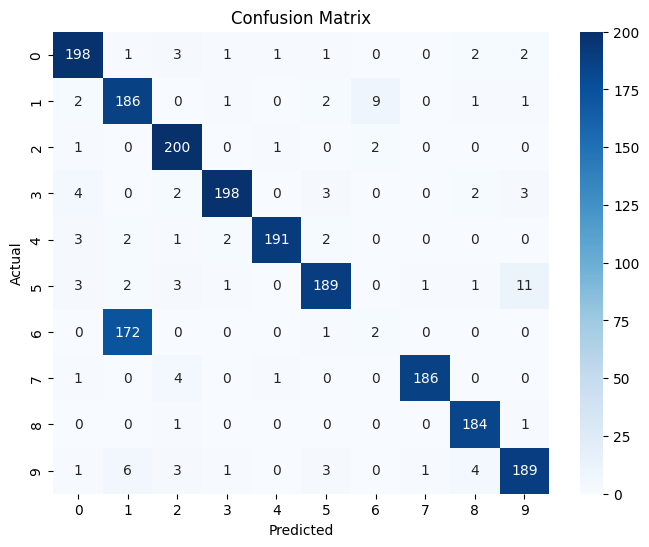

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

import joblib
from sklearn.preprocessing import StandardScaler

model.save("language_model.keras")

joblib.dump(scaler, "scaler.pkl")

joblib.dump(encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [ ]:
import joblib

# Save trained model
model.save("language_model.keras")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save label encoder
joblib.dump(encoder, "label_encoder.pkl")

import os
print(os.listdir())

['.config', 'label_encoder.pkl', 'dataset', 'scaler.pkl', 'drive', 'language_model.keras', 'sample_data']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from tensorflow.keras.models import load_model
import joblib

model = load_model("./language_model.keras")

scaler = joblib.load("./scaler.pkl")
encoder = joblib.load("./label_encoder.pkl")

print("Model and files loaded successfully")

Model and files loaded successfully


In [ ]:
import librosa
import numpy as np

def extract_features(file_path):

    audio, sr = librosa.load(file_path, duration=3)

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

    mfcc_scaled = np.mean(mfcc.T, axis=0)

    return mfcc_scaled

In [ ]:


file_path = "262.mp3"

features = extract_features(file_path)

features = features.reshape(1,-1)

features = scaler.transform(features)

prediction = model.predict(features)

predicted_label = np.argmax(prediction)

language = encoder.inverse_transform([predicted_label])

print("Predicted Language:", language[0])



/tmp/ipykernel_29681/2543693117.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, duration=3)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


FileNotFoundError: [Errno 2] No such file or directory: '262.mp3'

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving 8609.mp3 to 8609 (1).mp3


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 262.mp3 to 262.mp3


In [ ]:
import os
import numpy as np

dataset_path = "/content/dataset/Indian_Languages_Audio_Dataset"

correct = 0
total = 0

for language in os.listdir(dataset_path):

    language_path = os.path.join(dataset_path, language)

    if not os.path.isdir(language_path):
        continue

    for file in os.listdir(language_path):

        if file.endswith(".mp3"):

            file_path = os.path.join(language_path, file)

            features = extract_features(file_path)

            if features is None:
                continue

            features = features.reshape(1,-1)

            features = scaler.transform(features)

            prediction = model.predict(features)

            predicted_label = np.argmax(prediction)

            predicted_language = encoder.inverse_transform([predicted_label])[0]

            total += 1

            if predicted_language == language:
                correct += 1

            print(file, "Actual:", language, "Predicted:", predicted_language)

accuracy = correct / total

print("Total Samples:", total)
print("Correct Predictions:", correct)
print("Accuracy:", accuracy * 100, "%")

Streaming output truncated to the last 5000 lines.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
12994.mp3 Actual: Marathi Predicted: Marathi
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
5596.mp3 Actual: Marathi Predicted: Marathi
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
6567.mp3 Actual: Marathi Predicted: Bengali
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
10192.mp3 Actual: Marathi Predicted: Marathi
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
20041.mp3 Actual: Marathi Predicted: Marathi
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
13141.mp3 Actual: Marathi Predicted: Marathi
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
8232.mp3 Actual: Marathi Predicted: Telugu
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
16532.mp3 Actual: Marathi Predicted: Marathi
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
8032.mp3 Actual: Marathi Predicted: Marathi
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1606.mp3 Actual: Marathi Predicted: Marathi
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
12769.mp3 Actual: Marathi Predicted: Marathi
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
141

KeyboardInterrupt: 

In [ ]:
import os
print(os.listdir("/content"))

import os

for language in os.listdir("/content/dataset"):
    language_path = os.path.join("/content/dataset", language)
    print(language, len(os.listdir(language_path)))

['.config', 'label_encoder.pkl', 'dataset', 'scaler.pkl', 'drive', 'language_model.keras', 'sample_data']
Indian_Languages_Audio_Dataset 10


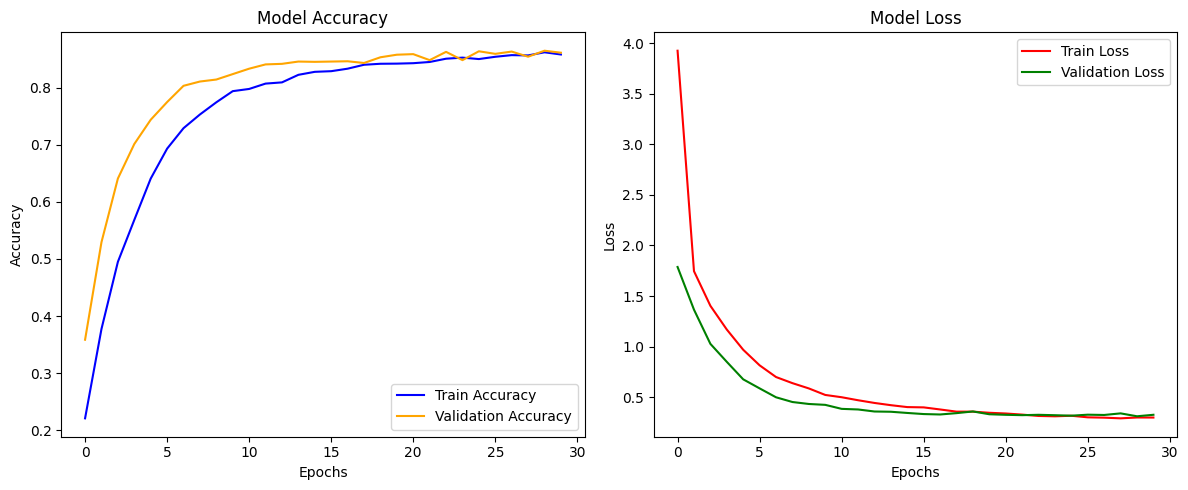

In [ ]:
import matplotlib.pyplot as plt

# Plot Training & Validation Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='green')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()